So far we've built quite a few models:

- Our own baseline CNN
- Pre-trained ResNet with new classifier
- Above plus additional fine tuning on last conv layer
- Pre-trained ResNet with new classifier, plus fine tuning on last conv layer, but using class-weighted loss function
- Fine tuning entire model

An important question is to have good ways to evaluate the performance of these and other models we we can select the best one.

We will also start buildign more re-usable code as we go.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torchvision.models import resnet18

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "metadata_splits.csv"
)

MODEL_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"

RESULTS_DIR.mkdir(exist_ok=True)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cuda


In [2]:
#Restore class definitions
CLASS_NAMES = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc",
]

NUM_CLASSES = len(CLASS_NAMES)

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(CLASS_NAMES)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

In [3]:
#load metadata
df = pd.read_csv(DATA_PATH)

# Image paths are stored relative to the project root
df["image_path"] = df["image_path"].map(lambda p: str(PROJECT_ROOT / p))

val_df = df[df["split"] == "val"].copy()
test_df = df[df["split"] == "test"].copy()

print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Validation images: 1532
Test images: 1481


In [9]:
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

In [ ]:
#Recreate data input pipeline
#Evaluation transform
#We don't need the train_transofmr in this notebook
IMAGE_SIZE = 224

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [11]:
#Dataset
class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = class_to_idx[row["dx"]]

        return image, label

In [12]:
#Create evaluation dataset
val_dataset = HAM10000Dataset(
    val_df,
    transform=eval_transform
)

print("Validation dataset:", len(val_dataset))

Validation dataset: 1532


In [16]:
#Now dataloader
BATCH_SIZE = 32

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [17]:
images, labels = next(iter(val_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])


In [18]:
#Function to load model
def load_resnet18_checkpoint(checkpoint_path, device):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
    )

    model = resnet18(weights=None)

    model.fc = nn.Linear(
        model.fc.in_features,
        NUM_CLASSES,
    )

    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    model = model.to(device)
    model.eval()

    return model, checkpoint

In [19]:
#Load our three models
partial_model, partial_checkpoint = (
    load_resnet18_checkpoint(
        MODEL_DIR / "resnet18_finetuned.pt",
        device,
    )
)

weighted_model, weighted_checkpoint = (
    load_resnet18_checkpoint(
        MODEL_DIR / "resnet18_finetuned_weighted.pt",
        device,
    )
)

full_model, full_checkpoint = (
    load_resnet18_checkpoint(
        MODEL_DIR / "resnet18_full_finetuned.pt",
        device,
    )
)

In [20]:
#Function to get predicitons
#THis is also updated to give us all probabilities, not just the single predicted class
def get_predictions(model, loader, device):
    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True,
            )

            outputs = model(images)

            probabilities = torch.softmax(
                outputs,
                dim=1,
            )

            predictions = probabilities.argmax(
                dim=1
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )

    return (
        np.array(all_labels),
        np.array(all_predictions),
        np.array(all_probabilities),
    )

In [21]:
#Test out the partial model
y_true, y_pred, y_prob = get_predictions(
    partial_model,
    val_loader,
    device,
)

print("Labels:", y_true.shape)
print("Predictions:", y_pred.shape)
print("Probabilities:", y_prob.shape)

Labels: (1532,)
Predictions: (1532,)
Probabilities: (1532, 7)


In [22]:
#Find metrics
def calculate_metrics(y_true, y_pred):

    metrics = {
        "accuracy": accuracy_score(
            y_true, y_pred
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_true, y_pred
        ),

        "macro_precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),

        "macro_recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),

        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
    }

    return metrics

In [23]:
partial_metrics = calculate_metrics(
    y_true,
    y_pred,
)

partial_metrics

{'accuracy': 0.7845953002610966,
 'balanced_accuracy': 0.610663186686855,
 'macro_precision': 0.5805921115825318,
 'macro_recall': 0.610663186686855,
 'macro_f1': 0.5900316423475614}

In [24]:
#Compare all three models
models = {
    "Partial fine-tune": partial_model,
    "Weighted fine-tune": weighted_model,
    "Full fine-tune": full_model,
}

validation_results = {}

for model_name, model in models.items():

    y_true_model, y_pred_model, y_prob_model = (
        get_predictions(
            model,
            val_loader,
            device,
        )
    )

    metrics = calculate_metrics(
        y_true_model,
        y_pred_model,
    )

    validation_results[model_name] = metrics

    print(f"Finished: {model_name}")

Finished: Partial fine-tune
Finished: Weighted fine-tune
Finished: Full fine-tune


In [25]:
results_df = (
    pd.DataFrame(validation_results)
    .T
)

results_df

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
Partial fine-tune,0.784595,0.610663,0.580592,0.610663,0.590032
Weighted fine-tune,0.723238,0.646794,0.564715,0.646794,0.591497
Full fine-tune,0.795692,0.600724,0.626890,0.600724,0.601805


In [26]:
display(
    results_df.style.format("{:.3f}")
)

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
Partial fine-tune,0.785,0.611,0.581,0.611,0.590
Weighted fine-tune,0.723,0.647,0.565,0.647,0.591
Full fine-tune,0.796,0.601,0.627,0.601,0.602


In [27]:
#Track probabilities as well
validation_results = {}
validation_predictions = {}

for model_name, model in models.items():

    y_true_model, y_pred_model, y_prob_model = (
        get_predictions(
            model,
            val_loader,
            device,
        )
    )

    validation_results[model_name] = (
        calculate_metrics(
            y_true_model,
            y_pred_model,
        )
    )

    validation_predictions[model_name] = {
        "y_true": y_true_model,
        "y_pred": y_pred_model,
        "y_prob": y_prob_model,
    }

results_df = pd.DataFrame(
    validation_results
).T

display(
    results_df.style.format("{:.3f}")
)

,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1
Partial fine-tune,0.785,0.611,0.581,0.611,0.590
Weighted fine-tune,0.723,0.647,0.565,0.647,0.591
Full fine-tune,0.796,0.601,0.627,0.601,0.602


### Confusion matrices

Move from "how often wrong" to "what kind of mistakes does it make".

In [28]:
partial_pred = validation_predictions[
    "Partial fine-tune"
]

y_true_partial = partial_pred["y_true"]
y_pred_partial = partial_pred["y_pred"]

In [29]:
cm = confusion_matrix(
    y_true_partial,
    y_pred_partial,
)

cm

array([[ 20,  10,  10,   3,   5,   2,   1],
       [  4,  54,   9,   6,   0,   2,   2],
       [  3,   5, 110,   1,  17,  17,   4],
       [  3,   3,   0,   9,   0,   4,   0],
       [  6,  10,  36,   0,  69,  47,   2],
       [  1,   7,  43,   5,  54, 923,   1],
       [  0,   1,   2,   0,   2,   2,  17]])

In [30]:
cm_normalized = confusion_matrix(
    y_true_partial,
    y_pred_partial,
    normalize="true",
)

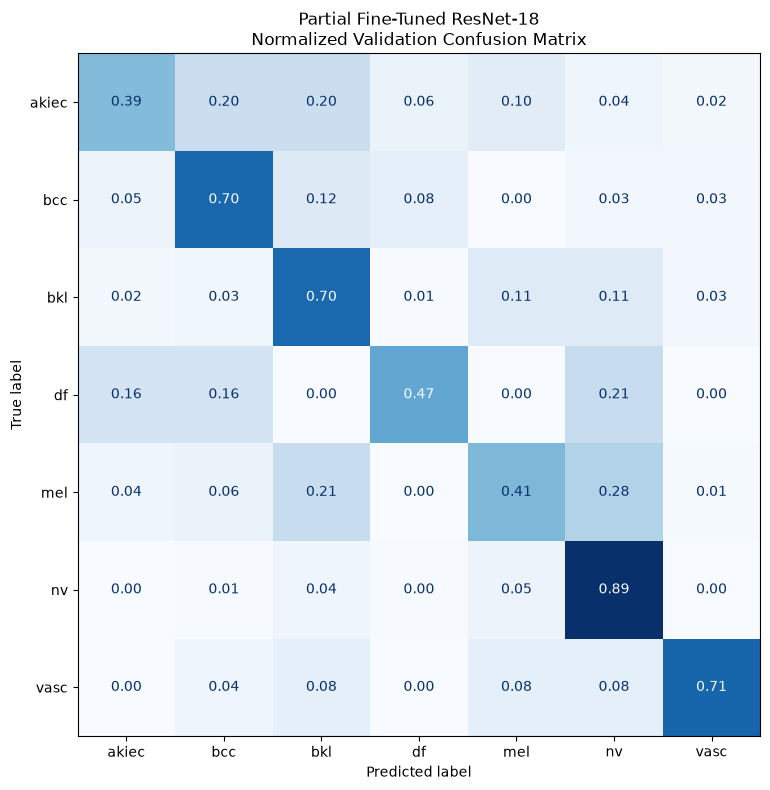

In [31]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(
    figsize=(8, 8)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=CLASS_NAMES,
)

disp.plot(
    cmap="Blues",
    values_format=".2f",
    ax=ax,
    colorbar=False,
)

ax.set_title(
    "Partial Fine-Tuned ResNet-18\n"
    "Normalized Validation Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [32]:
def plot_normalized_confusion_matrix(
    y_true,
    y_pred,
    class_names,
    title,
):
    cm = confusion_matrix(
        y_true,
        y_pred,
        normalize="true",
    )

    fig, ax = plt.subplots(
        figsize=(8, 8)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )

    disp.plot(
        cmap="Blues",
        values_format=".2f",
        ax=ax,
        colorbar=False,
    )

    ax.set_title(title)

    plt.tight_layout()
    plt.show()

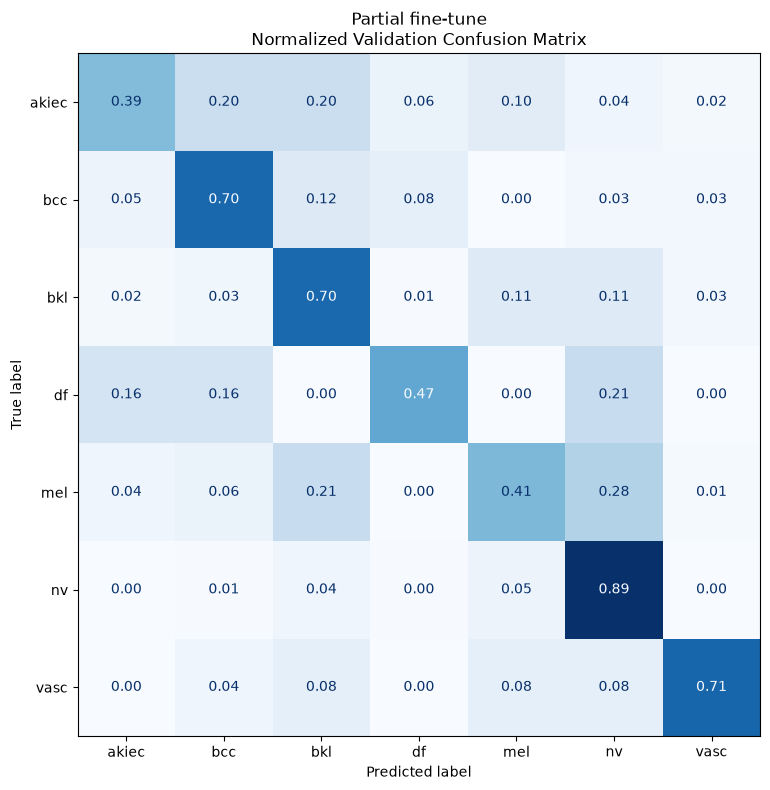

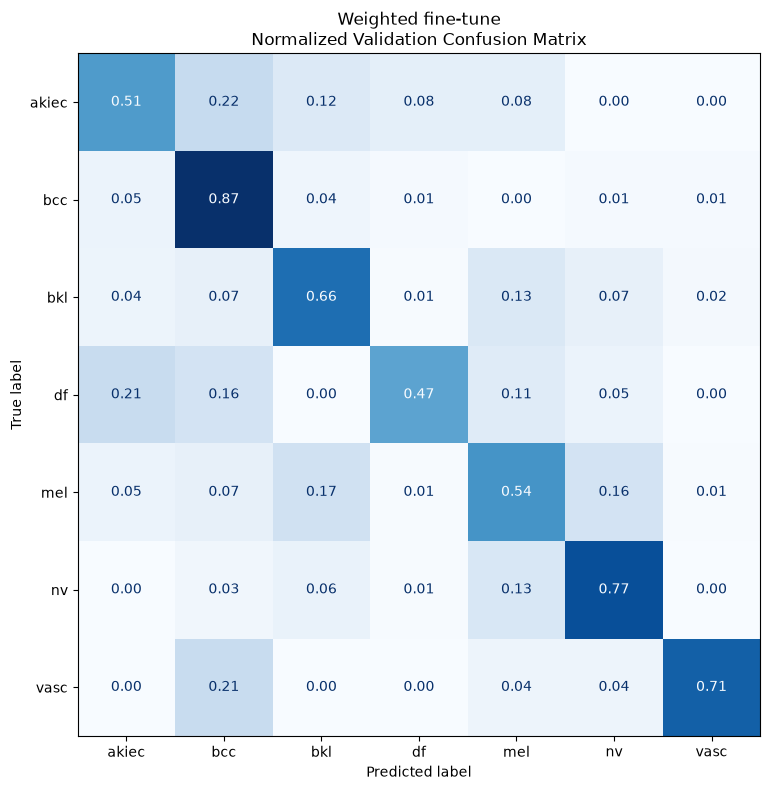

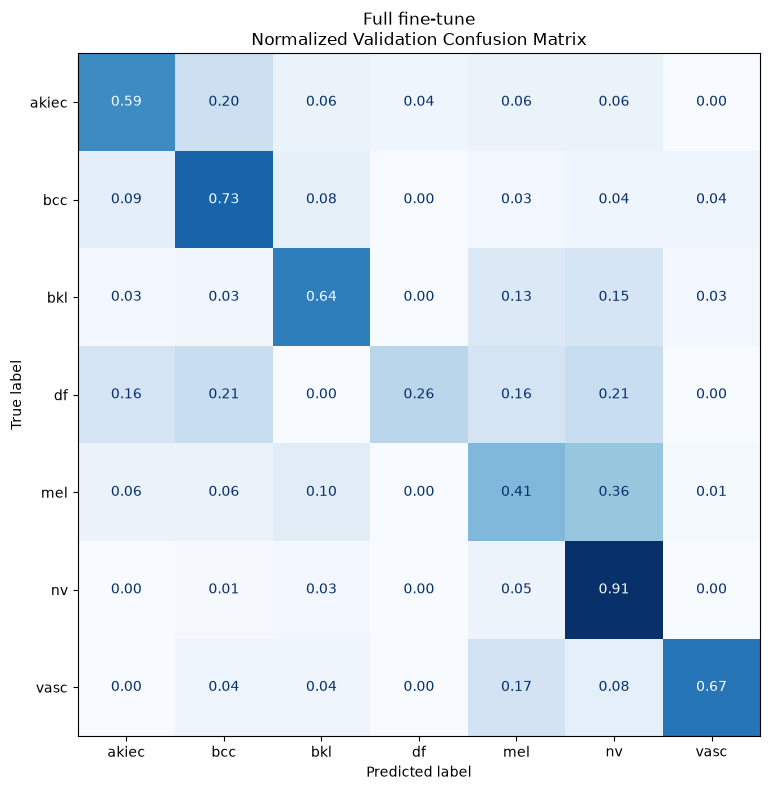

In [33]:
for model_name, predictions in (
    validation_predictions.items()
):

    plot_normalized_confusion_matrix(
        predictions["y_true"],
        predictions["y_pred"],
        CLASS_NAMES,
        f"{model_name}\n"
        "Normalized Validation Confusion Matrix",
    )

Consider mel (melanoma) vs non-melanoma as one vs rest.

In [34]:
mel_idx = class_to_idx["mel"]

print("Melanoma class index:", mel_idx)

Melanoma class index: 4


In [35]:
def melanoma_metrics(y_true, y_pred):

    y_true_mel = (y_true == mel_idx).astype(int)
    y_pred_mel = (y_pred == mel_idx).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true_mel,
        y_pred_mel
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    false_negative_rate = fn / (tp + fn)
    false_positive_rate = fp / (tn + fp)

    return {
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "false_negative_rate": false_negative_rate,
        "false_positive_rate": false_positive_rate,
    }

In [36]:
melanoma_results = {}

for model_name, predictions in (
    validation_predictions.items()
):

    melanoma_results[model_name] = (
        melanoma_metrics(
            predictions["y_true"],
            predictions["y_pred"],
        )
    )

melanoma_df = pd.DataFrame(
    melanoma_results
).T

display(
    melanoma_df.style.format({
        "TP": "{:.0f}",
        "TN": "{:.0f}",
        "FP": "{:.0f}",
        "FN": "{:.0f}",
        "sensitivity": "{:.3f}",
        "specificity": "{:.3f}",
        "false_negative_rate": "{:.3f}",
        "false_positive_rate": "{:.3f}",
    })
)

,TP,TN,FP,FN,sensitivity,specificity,false_negative_rate,false_positive_rate
Partial fine-tune,69,1284,78,101,0.406,0.943,0.594,0.057
Weighted fine-tune,91,1196,166,79,0.535,0.878,0.465,0.122
Full fine-tune,70,1276,86,100,0.412,0.937,0.588,0.063


In [38]:
partial_data = validation_predictions[
    "Partial fine-tune"
]

y_true = partial_data["y_true"]
y_prob = partial_data["y_prob"]

y_true_mel = (y_true == mel_idx).astype(int)
mel_prob = y_prob[:, mel_idx]

print("First 10 melanoma probabilities:")
print(mel_prob[:10])

print("\nMin:", mel_prob.min())
print("Max:", mel_prob.max())

First 10 melanoma probabilities:
[2.9983010e-02 1.5045566e-02 2.8657669e-03 1.9298028e-04 5.5305324e-02
 3.4621352e-01 2.3562469e-01 6.2154834e-03 6.0960926e-02 5.9094794e-02]

Min: 1.76771e-11
Max: 0.999316


In [39]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
)

In [40]:
fpr, tpr, thresholds = roc_curve(
    y_true_mel,
    mel_prob,
)

auc = roc_auc_score(
    y_true_mel,
    mel_prob,
)

print(f"Melanoma ROC AUC: {auc:.3f}")

Melanoma ROC AUC: 0.858


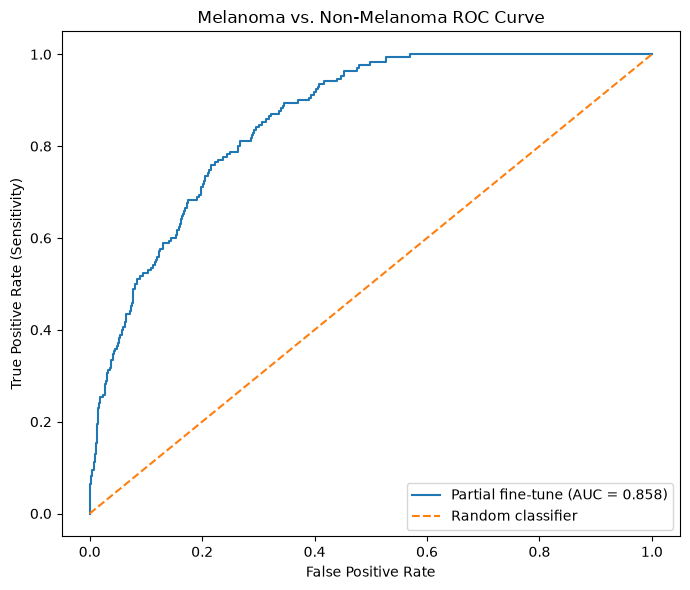

In [41]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Partial fine-tune (AUC = {auc:.3f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("Melanoma vs. Non-Melanoma ROC Curve")
plt.legend()

plt.tight_layout()
plt.show()

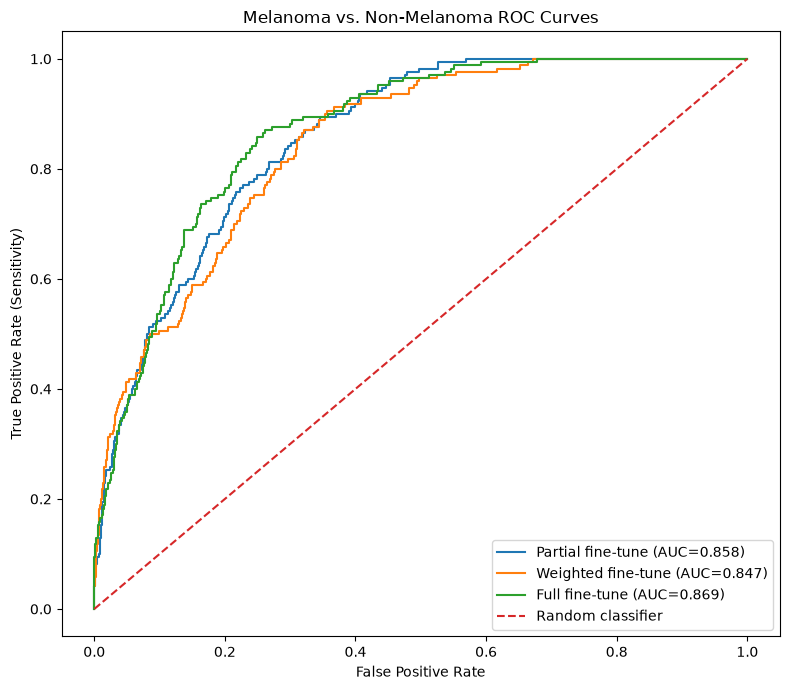

In [42]:
plt.figure(figsize=(8, 7))

mel_auc_results = {}

for model_name, predictions in (
    validation_predictions.items()
):

    y_true = predictions["y_true"]
    y_prob = predictions["y_prob"]

    y_true_mel = (
        y_true == mel_idx
    ).astype(int)

    mel_prob = y_prob[:, mel_idx]

    fpr, tpr, thresholds = roc_curve(
        y_true_mel,
        mel_prob,
    )

    auc = roc_auc_score(
        y_true_mel,
        mel_prob,
    )

    mel_auc_results[model_name] = auc

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={auc:.3f})",
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title(
    "Melanoma vs. Non-Melanoma ROC Curves"
)
plt.legend()

plt.tight_layout()
plt.show()

In [43]:
mel_auc_results

{'Partial fine-tune': 0.8580677204802625,
 'Weighted fine-tune': 0.8473179580202125,
 'Full fine-tune': 0.8692709682992139}

In [44]:
def melanoma_threshold_metrics(
    y_true,
    y_prob,
    threshold,
):
    y_true_mel = (
        y_true == mel_idx
    ).astype(int)

    mel_prob = y_prob[:, mel_idx]

    y_pred_mel = (
        mel_prob >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true_mel,
        y_pred_mel,
    ).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)

    return {
        "threshold": threshold,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "sensitivity": sensitivity,
        "specificity": specificity,
    }

In [45]:
full_predictions = validation_predictions[
    "Full fine-tune"
]

full_y_true = full_predictions["y_true"]
full_y_prob = full_predictions["y_prob"]

In [46]:
thresholds_to_test = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
]

threshold_results = []

for threshold in thresholds_to_test:

    result = melanoma_threshold_metrics(
        full_y_true,
        full_y_prob,
        threshold,
    )

    threshold_results.append(result)

threshold_df = pd.DataFrame(
    threshold_results
)

display(
    threshold_df.style.format({
        "threshold": "{:.2f}",
        "TP": "{:.0f}",
        "FP": "{:.0f}",
        "TN": "{:.0f}",
        "FN": "{:.0f}",
        "sensitivity": "{:.3f}",
        "specificity": "{:.3f}",
    })
)

,threshold,TP,FP,TN,FN,sensitivity,specificity
0,0.10,125,231,1131,45,0.735,0.830
1,0.20,98,154,1208,72,0.576,0.887
2,0.30,84,120,1242,86,0.494,0.912
3,0.40,73,98,1264,97,0.429,0.928
4,0.50,66,77,1285,104,0.388,0.943
5,0.60,58,54,1308,112,0.341,0.960
6,0.70,50,45,1317,120,0.294,0.967


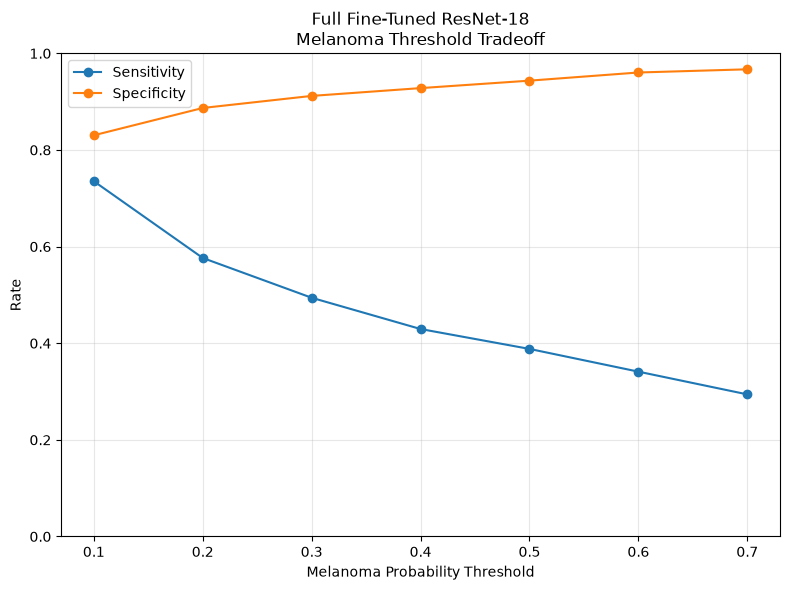

In [47]:
plt.figure(figsize=(8, 6))

plt.plot(
    threshold_df["threshold"],
    threshold_df["sensitivity"],
    marker="o",
    label="Sensitivity",
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["specificity"],
    marker="o",
    label="Specificity",
)

plt.xlabel("Melanoma Probability Threshold")
plt.ylabel("Rate")
plt.title(
    "Full Fine-Tuned ResNet-18\n"
    "Melanoma Threshold Tradeoff"
)

plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
fine_thresholds = np.arange(
    0.01,
    1.00,
    0.01,
)

fine_results = []

for threshold in fine_thresholds:

    result = melanoma_threshold_metrics(
        full_y_true,
        full_y_prob,
        threshold,
    )

    fine_results.append(result)

fine_threshold_df = pd.DataFrame(
    fine_results
)

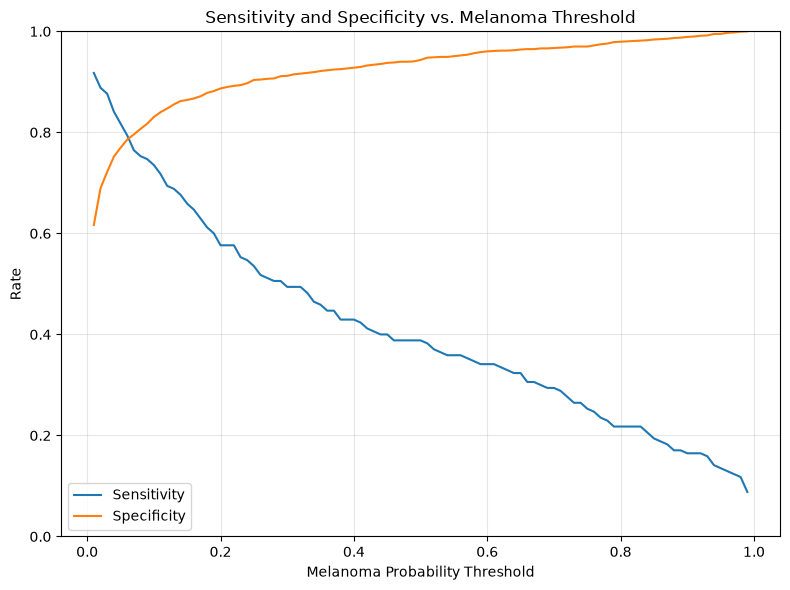

In [49]:
plt.figure(figsize=(8, 6))

plt.plot(
    fine_threshold_df["threshold"],
    fine_threshold_df["sensitivity"],
    label="Sensitivity",
)

plt.plot(
    fine_threshold_df["threshold"],
    fine_threshold_df["specificity"],
    label="Specificity",
)

plt.xlabel("Melanoma Probability Threshold")
plt.ylabel("Rate")
plt.title(
    "Sensitivity and Specificity vs. "
    "Melanoma Threshold"
)

plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Threshold analysis demonstrates the sensitivity-specificity tradeoff for melanoma detection. No clinically optimal threshold is claimed; threshold selection would require a predefined intended use, acceptable error rates, and external clinical validation.

### Model Selection
For this project, I suggest we define our selection rule as:
Primary metric: validation macro F1. Use melanoma ROC-AUC and balanced accuracy as complementary metrics to characterize important tradeoffs rather than combining them into an arbitrary score.

Why macro F1? Because HAM10000 is strongly imbalanced, and macro F1 gives each of the seven classes equal weight while accounting for both precision and recall.

In [50]:
selected_model_name = (
    results_df["macro_f1"].idxmax()
)

selected_model_name

'Full fine-tune'

### Model Selection Decision

The fully fine-tuned ResNet-18 was selected using validation
macro F1 as the primary model-selection metric.

Validation performance:

- Accuracy: 0.796
- Balanced accuracy: 0.601
- Macro F1: 0.602
- Melanoma ROC-AUC: 0.869

The weighted fine-tuned model achieved higher balanced accuracy
(0.647) and higher melanoma sensitivity under the multiclass
argmax decision rule, demonstrating the tradeoff between
minority-class recall and overall classification performance.

Threshold analysis also showed that melanoma sensitivity and
specificity can be adjusted at inference time without retraining.

No clinically optimal decision threshold is claimed. The model
and threshold analyses are for educational/research purposes and
would require external clinical validation before any clinical use.

Now find the TEST performance so we have unbiased estimation of its performance.

In [51]:
test_dataset = HAM10000Dataset(
    test_df,
    transform=eval_transform,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print("Test images:", len(test_dataset))

Test images: 1481


In [52]:
test_y_true, test_y_pred, test_y_prob = (
    get_predictions(
        full_model,
        test_loader,
        device,
    )
)

test_metrics = calculate_metrics(
    test_y_true,
    test_y_pred,
)

test_metrics

{'accuracy': 0.8284942606347063,
 'balanced_accuracy': 0.6430343725089882,
 'macro_precision': 0.718357406147157,
 'macro_recall': 0.6430343725089882,
 'macro_f1': 0.6658364385034867}

In [53]:
print(
    classification_report(
        test_y_true,
        test_y_pred,
        target_names=CLASS_NAMES,
        digits=3,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

       akiec      0.551     0.587     0.568        46
         bcc      0.595     0.704     0.645        71
         bkl      0.708     0.720     0.714       168
          df      0.778     0.350     0.483        20
         mel      0.626     0.588     0.606       165
          nv      0.914     0.920     0.917       992
        vasc      0.857     0.632     0.727        19

    accuracy                          0.828      1481
   macro avg      0.718     0.643     0.666      1481
weighted avg      0.829     0.828     0.827      1481



In [54]:
test_y_true_mel = (
    test_y_true == mel_idx
).astype(int)

test_mel_prob = test_y_prob[
    :, mel_idx
]

test_mel_auc = roc_auc_score(
    test_y_true_mel,
    test_mel_prob,
)

print(
    f"Test melanoma ROC-AUC: "
    f"{test_mel_auc:.3f}"
)

Test melanoma ROC-AUC: 0.905


In [55]:
#Save results
final_results = {
    "model": "ResNet-18",
    "training_strategy": "Full fine-tuning",
    "selection_metric": "Validation macro F1",
    "test_accuracy": test_metrics["accuracy"],
    "test_balanced_accuracy": (
        test_metrics["balanced_accuracy"]
    ),
    "test_macro_precision": (
        test_metrics["macro_precision"]
    ),
    "test_macro_recall": (
        test_metrics["macro_recall"]
    ),
    "test_macro_f1": (
        test_metrics["macro_f1"]
    ),
    "test_melanoma_auc": test_mel_auc,
}

pd.Series(final_results)

model                               ResNet-18
training_strategy            Full fine-tuning
selection_metric          Validation macro F1
test_accuracy                        0.828494
test_balanced_accuracy               0.643034
test_macro_precision                 0.718357
test_macro_recall                    0.643034
test_macro_f1                        0.665836
test_melanoma_auc                    0.905117
dtype: object

In [56]:
results_path = (
    RESULTS_DIR
    / "resnet18_final_test_metrics.csv"
)

pd.DataFrame(
    [final_results]
).to_csv(
    results_path,
    index=False,
)

print("Saved:", results_path)

Saved: results/resnet18_final_test_metrics.csv


## Final Evaluation Summary

A fully fine-tuned ImageNet-pretrained ResNet-18 was selected
using validation macro F1 as the primary model-selection
criterion.

The selected model was then evaluated once on the held-out test
set of 1,481 images.

### Test Results

- Accuracy: 0.828
- Balanced accuracy: 0.643
- Macro precision: 0.718
- Macro recall: 0.643
- Macro F1: 0.666
- Melanoma ROC-AUC: 0.905

Performance varied substantially across diagnostic classes.
Melanoma recall under the seven-class argmax decision rule was
0.588, while melanoma ROC-AUC was 0.905, demonstrating that
classification performance depends strongly on the decision rule
and threshold.

Threshold analysis on the validation set demonstrated the
tradeoff between melanoma sensitivity and specificity. No
clinically optimal threshold was selected.

The dataset does not contain a patient identifier, so the
train/validation/test split prevents lesion-level overlap but
cannot guarantee patient-level independence.

These results describe performance on the HAM10000 dataset and
should not be interpreted as evidence of clinical validity.
External validation and clinically defined operating criteria
would be required before considering clinical use.